### 연습 문제
1. 5월 19일에 작업했던 하이닉스 주식 데이터를 로드하는 방법(야후 파이낸스)을 이용
    - 야후 파이낸스에서 일별 데이터를 로드하는 기간은 2000년도 이후부터 가능
2. opendartreader 라이브러리를 이용해서 영업이익 데이터를 로드
    - env 활용해서 api_key 데이터 공유 금지
    - Dart 전자공시 2015년부터 전자공시 필수화 (15년 이후의 공시 데이터는 서치 가능)
    - 15년 이전의 데이터들은 웹 크롤링을 이용하여 노가다 작업
3. 주가의 데이터는 15년부터 불러오고 영업이익 데이터도 15년부터 데이터를 로드하여 데이터를 결합
    - 영업이익이 존재하지 않는 데이터들은 제거 (결측치 제거)
4. 이동 평균선(20일)을 생성하고 이격도 컬럼을 생성
5. 종가, 거래량, 이격도, 영업이익 데이터를 이용하여 LSTM 모델에 학습 데이터로 이용
6. train : test = 85 :15로 생성하여 데이터 예측 모델을 생성
7. epoch=20, window=60, 학습 batch 개수 = 64, 검증 batch 개수 = 32, lr=0.001    

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from opendartreader import OpenDartReader
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datetime import datetime
import os
from dotenv import load_dotenv
import time

In [2]:
#1
#sk하이닉스 데이터를 수집
hynix = yf.Ticker('000660.KS')
#최근 2년 간의 데이터를 추출
# df= hynix.history(period='12y')
df=hynix.history(start='2015-01-01')
# df=df.loc[df.loc>'2015-01-01']
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-01-02 00:00:00+09:00,41592.274824,41982.608999,41332.052041,41418.792969,1155944,0.0,0.0
2015-01-05 00:00:00+09:00,41679.010542,41982.603751,41201.935500,41332.046875,1409146,0.0,0.0
2015-01-06 00:00:00+09:00,40768.229030,41288.674507,40681.488117,41201.933594,1661196,0.0,0.0
2015-01-07 00:00:00+09:00,40508.001187,41288.669304,40508.001187,41115.187500,1821266,0.0,0.0
2015-01-08 00:00:00+09:00,41852.497967,43370.464214,41548.904717,43327.093750,5006675,0.0,0.0


In [3]:
#종가, 거래량을 제오한 나머지 컬럼들을 제외 (특정 컬럼만 선택)
df=df[['Close','Volume']]
#이동평균선
df['MA20']=df['Close'].rolling(20).mean()
df.head()

,Close,Volume,MA20
Date,,,
2015-01-02 00:00:00+09:00,41418.792969,1155944,NaN
2015-01-05 00:00:00+09:00,41332.046875,1409146,NaN
2015-01-06 00:00:00+09:00,41201.933594,1661196,NaN
2015-01-07 00:00:00+09:00,41115.187500,1821266,NaN
2015-01-08 00:00:00+09:00,43327.093750,5006675,NaN


In [4]:
#.env 파일에서 환경변수 로드
load_dotenv()

# OpenDART API 인증키 설정 (본인의 API 키)
api_key=os.getenv('api_key')

#dart에서 데이터를 수집
dart=OpenDartReader(api_key)

In [5]:
#2
#2015년부터 2025년까지 년도별 영업이익을 구하기 위해 연도 List 생성
#현재의 년도
current_year = datetime.now().year
years =range(2015, current_year+1)
years

range(2015, 2027)

In [6]:
#보고서 리스트 성
reprt_codes = ['11013', '11012', '11014', '11011']
dart_data_list=[]

In [7]:
for year in years:
    for code in reprt_codes:
        try:
            report=dart.finstate('000660',year,code)
            if report is not None:
                op_profit = report[(report['fs_div']=='CFS') & (report['account_nm']=='영업이익')]
                if not op_profit.empty:
                    val=int(
                        op_profit['thstrm_amount'].values[0].replace(',','')
                        )
                    #
                    if code =='11013':d=f'{year}-05-15'
                    elif code=='11012':d=f'{year}-08-14'
                    elif code =='11014':d=f'{year}-11-14'
                    else: d=f'{year+1}-03-31'

                    report_data=pd.to_datetime(d)
                    if report_data <= datetime.now():
                        dart_data_list.append({'Date' : report_data, 'Operation_Profit':val})
            time.sleep(1)
        except: continue

dart_data_list


{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}



[{'Date': Timestamp('2016-11-14 00:00:00'), 'Operation_Profit': 725956000000},
 {'Date': Timestamp('2017-03-31 00:00:00'), 'Operation_Profit': 3276746000000},
 {'Date': Timestamp('2017-05-15 00:00:00'), 'Operation_Profit': 2467599000000},
 {'Date': Timestamp('2017-08-14 00:00:00'), 'Operation_Profit': 3050700000000},
 {'Date': Timestamp('2017-11-14 00:00:00'), 'Operation_Profit': 3737193000000},
 {'Date': Timestamp('2018-03-31 00:00:00'),
  'Operation_Profit': 13721326000000},
 {'Date': Timestamp('2018-05-15 00:00:00'), 'Operation_Profit': 4367338000000},
 {'Date': Timestamp('2018-08-14 00:00:00'), 'Operation_Profit': 5573918000000},
 {'Date': Timestamp('2018-11-14 00:00:00'), 'Operation_Profit': 6472420000000},
 {'Date': Timestamp('2019-03-31 00:00:00'),
  'Operation_Profit': 20843750000000},
 {'Date': Timestamp('2020-08-14 00:00:00'), 'Operation_Profit': 1946715000000},
 {'Date': Timestamp('2020-11-14 00:00:00'), 'Operation_Profit': 1299696000000},
 {'Date': Timestamp('2021-03-31 00:

In [8]:
#시간, 영업이익 데이터를 데이터프레임으로 생성
dart_df = pd.DataFrame(dart_data_list)
dart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              26 non-null     datetime64[ns]
 1   Operation_Profit  26 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 548.0 bytes


In [9]:
display(df.head(1))
display(dart_df.head(1))

,Close,Volume,MA20
Date,,,
2015-01-02 00:00:00+09:00,41418.792969,1155944,NaN


,Date,Operation_Profit
0,2016-11-14,725956000000


In [10]:
#결합 전 df의 timezone을 제거
df.index = df.index.tz_localize(None)
df.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18',
               '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22',
               '2026-05-26', '2026-05-27'],
              dtype='datetime64[ns]', name='Date', length=2793, freq=None)

In [11]:
df = pd.merge_asof(df, dart_df,left_index=True, right_on='Date', direction='backward')
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2793 entries, 2015-01-02 to 2026-05-27
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Close             2793 non-null   float64       
 1   Volume            2793 non-null   int64         
 2   MA20              2774 non-null   float64       
 3   Date              2793 non-null   datetime64[ns]
 4   Operation_Profit  2332 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 130.9 KB


In [12]:
#4
#결측치가 포함되어있는 인덱스는 제거
df.dropna(inplace=True)

In [13]:
#이격도
df['Dist_MA20'] = (df['Close'] - df['MA20']) / df['MA20']

In [14]:
x=df[['Close', 'Volume', 'Operation_Profit', 'Dist_MA20']].values
y=df[['Close']].values

In [15]:
#6
split_index = int(len(df) * 0.85)

X_train, X_test = x[:split_index], x[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [16]:
x_scaler = MinMaxScaler().fit(X_train)
y_scaler = MinMaxScaler().fit(y_train)

X_train_sc=x_scaler.transform(X_train)
X_test_sc=x_scaler.transform(X_test)
y_train_sc=y_scaler.transform(y_train)
y_test_sc=y_scaler.transform(y_test)

In [17]:
#7
#딥러닝 초기 값들을 미리 지정
window=60
epochs=20
train_batch=32
test_batch=32
lr=0.001
hidden_cnt=64
head_type='c'

In [18]:
class windowDS(Dataset):
    def __init__(self, _x, _y, _window):
        self.x = _x
        self.y =_y
        self.window = _window
        self.n = len(_x) - _window
    
    def __len__(self):
        return self.n
    
    def __getitem__(self, idx):
        x = self.x[idx : idx + self.window]
        y = self.y[idx + self.window]

        x_tensor = torch.from_numpy(x)
        y_tensor = torch.tensor(y)

        return x_tensor, y_tensor

In [19]:
#DS생성
train_ds = windowDS(X_train_sc, y_train_sc, window)
test_ds = windowDS(X_test_sc, y_test_sc, window)

In [20]:
#DataLoader 생성
train_dl = DataLoader(train_ds, shuffle=True,drop_last=True,batch_size=train_batch)
test_dl = DataLoader(test_ds, shuffle=False,drop_last=False,batch_size=test_batch)

In [21]:
#5
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
                        feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
            feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)

In [22]:
model = LSTMModel(input_size=x.shape[1], hidden_size=hidden_cnt, head_type=head_type)
model
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [23]:
#검증 데이터를 이용하여 mse 값을 구하는 함수
@torch.no_grad()
def evaluate_mse(dl):
    model.eval()
    total_loss, total_n =0.0, 0
    for x, y in dl:
        x=x.float()
        y=y.float()
        pred=model(x)
        loss=criterion(pred,y)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    return total_loss / max(total_n, 1)


In [24]:
for epoch in range(epochs):
    model.train()
    total_loss, total_n = 0.0, 0
    for x, y in train_dl:
        x = x.float()
        y = y.float()

        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    train_loss = total_loss / max(total_n, 1)
    test_loss = evaluate_mse(test_dl)

    print(f"Epoch : {epoch}, train_mse : {train_loss}, test_loss : {test_loss}")

Epoch : 0, train_mse : 0.03221855223722135, test_loss : 0.5766695954162498
Epoch : 1, train_mse : 0.002299047614602993, test_loss : 0.4557788065538324
Epoch : 2, train_mse : 0.0005203735723625869, test_loss : 0.728966182072101
Epoch : 3, train_mse : 0.000374727545689287, test_loss : 0.9941601613986081
Epoch : 4, train_mse : 0.00036739317498965345, test_loss : 1.0769075056602215
Epoch : 5, train_mse : 0.0003515601986388598, test_loss : 1.0127228626403315
Epoch : 6, train_mse : 0.00029785122569592204, test_loss : 1.0589266009371856
Epoch : 7, train_mse : 0.0003218692738300888, test_loss : 1.0907891304842356
Epoch : 8, train_mse : 0.0002939664388880677, test_loss : 1.1375449682104177
Epoch : 9, train_mse : 0.0002964524353349892, test_loss : 1.058758087931522
Epoch : 10, train_mse : 0.00029305793771830697, test_loss : 1.0579808421818346
Epoch : 11, train_mse : 0.00029783315646151703, test_loss : 1.0885580373092971
Epoch : 12, train_mse : 0.0002806175329169491, test_loss : 1.092340579526177

In [25]:
model.eval()

preds=[]
trues=[]

with torch.no_grad():
    for x, y in test_dl:
        x=x.float()
        pred=model(x)
        preds.append(pred)
        trues.append(y)

preds=torch.cat(preds,dim=0).numpy()
trues=torch.cat(trues,dim=0).numpy()

pred_origin = y_scaler.inverse_transform(preds).squeeze()
true_origin = y_scaler.inverse_transform(trues).squeeze()

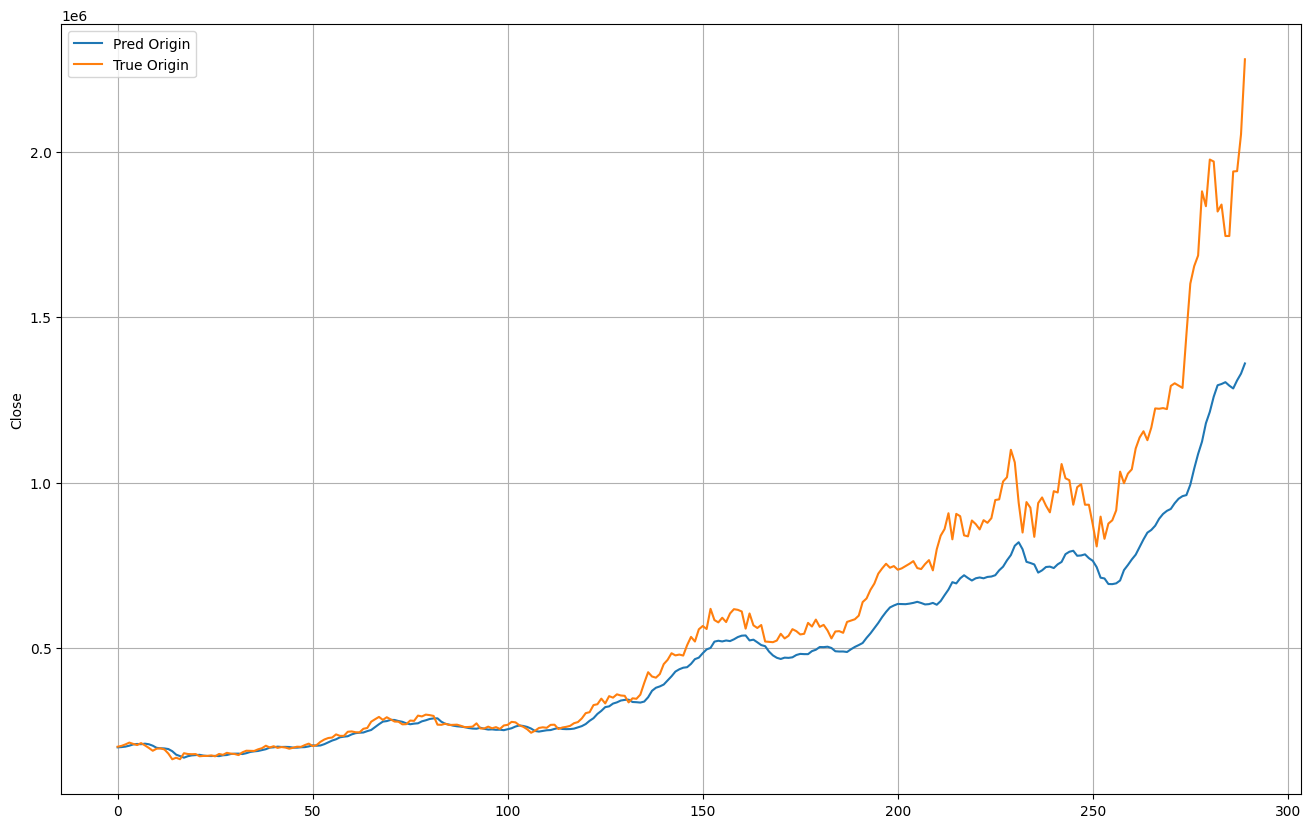

In [26]:
plt.figure(figsize=(16,10))

plt.plot(pred_origin, label='Pred Origin')
plt.plot(true_origin, label='True Origin')
plt.legend()
plt.grid()
plt.ylabel('Close')
#그림으로 저장
plt.savefig('하이닉스.png')
plt.show()